<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [10]</a>'.</span>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
from pathlib import Path

In [2]:
BASE_PATH = f'../Dataset/{Path().resolve().name}'
BASE_PATH

'../Dataset/dataset_regions'

In [3]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(f) for f in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)     
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = BASE_PATH.split('/')[-1].strip()
OPTIONS

{'network': 'unet3d_v2',
 'dataset': 'dataset_regions',
 'img_size': None,
 'lr': 0.0001,
 'loss': 'smooth_dice',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.0,
 'num_filters': 32}

In [4]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4) 

# CONVERTENDO IMAGENS

In [5]:
images = getFiles('original/*/images')
masks  = getFiles('original/*/masks')

print(images[0])
print(masks[0])

/home/grva-mint/Projects/Falhas/Dataset/dataset_regions/original/faulted/images/img_0000.npy
/home/grva-mint/Projects/Falhas/Dataset/dataset_regions/original/faulted/masks/img_0000.npy




 showing index 0: img_0000.npy


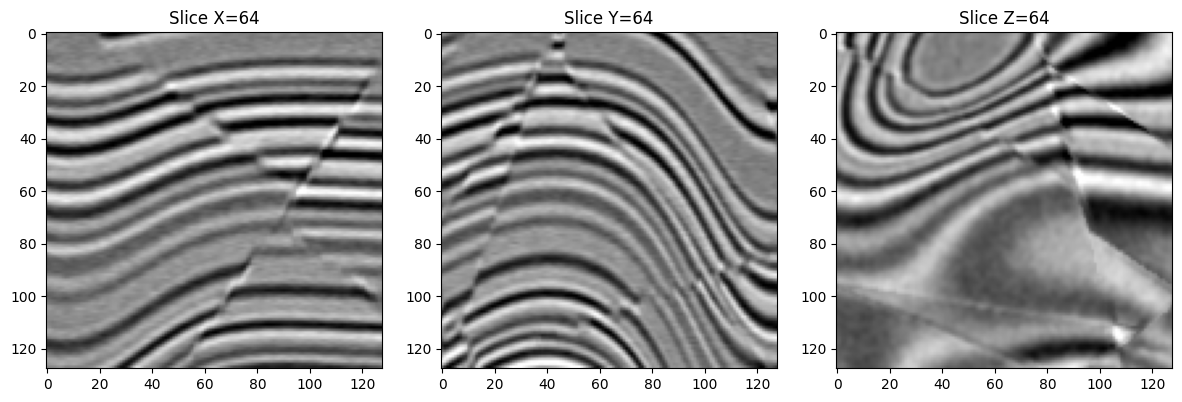

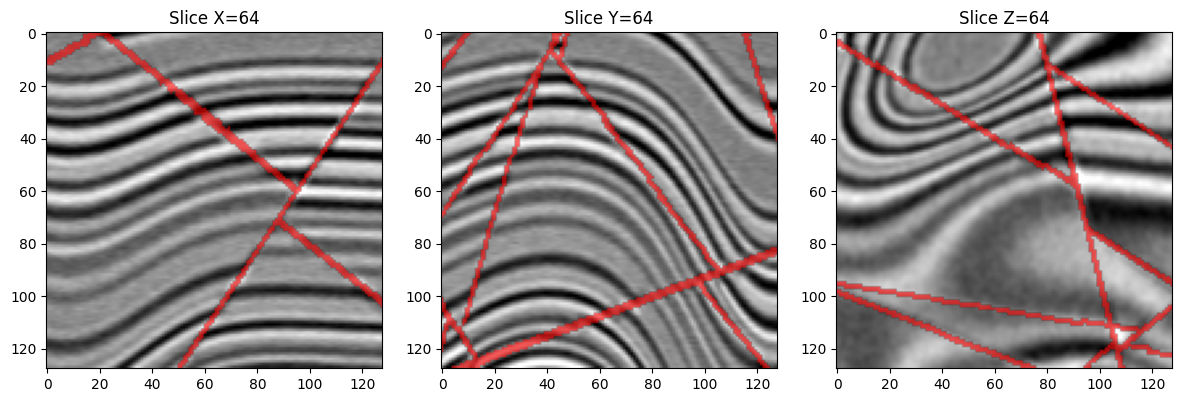



 showing index 1: img_0025.npy


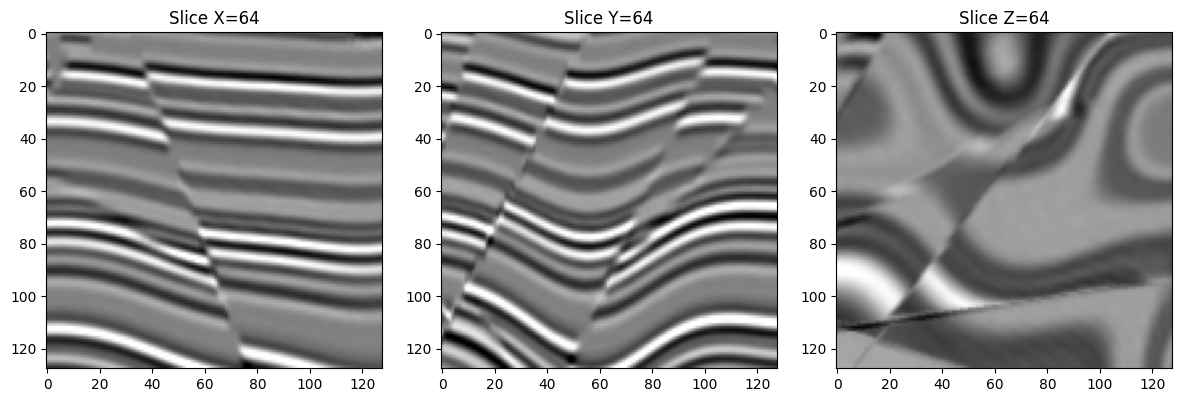

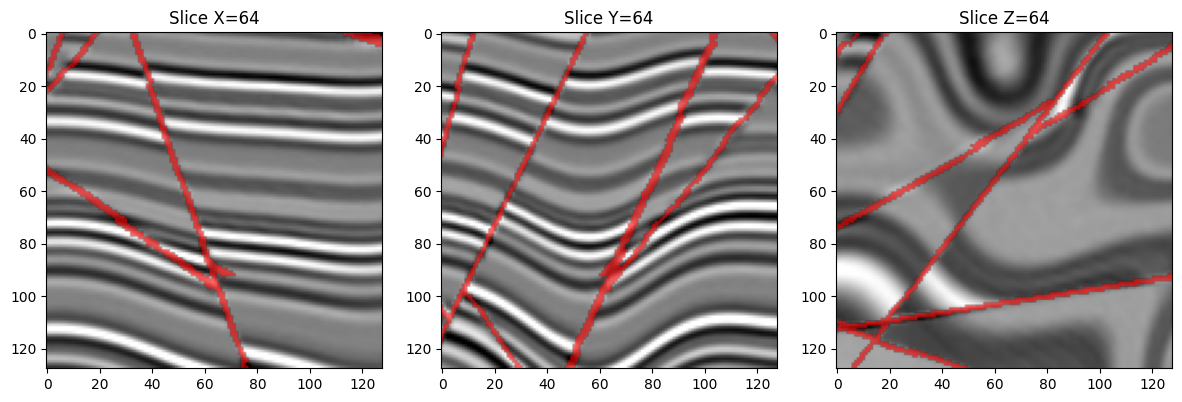



 showing index 2: img_0050.npy


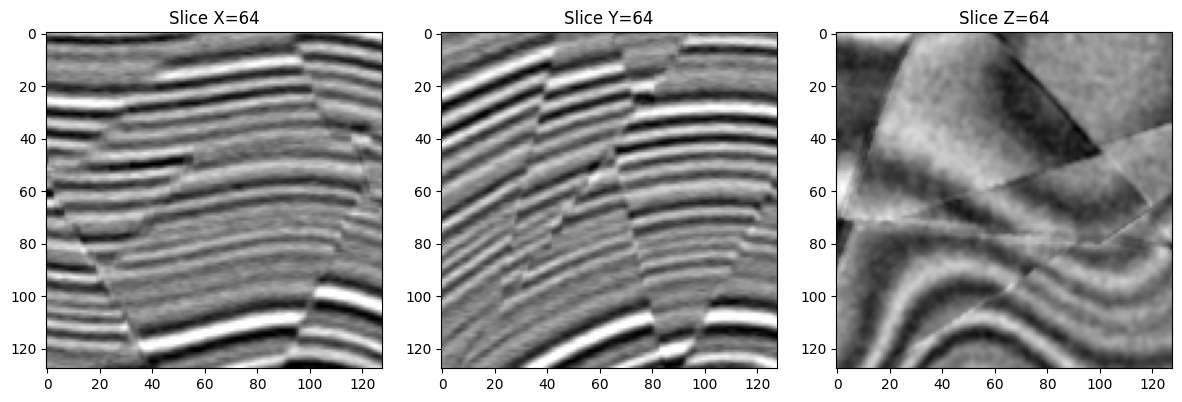

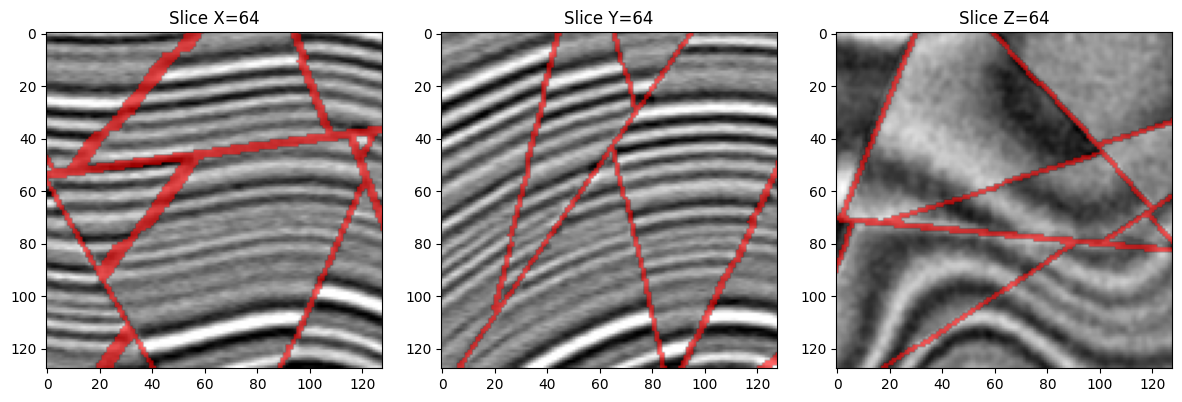



 showing index 3: img_0075.npy


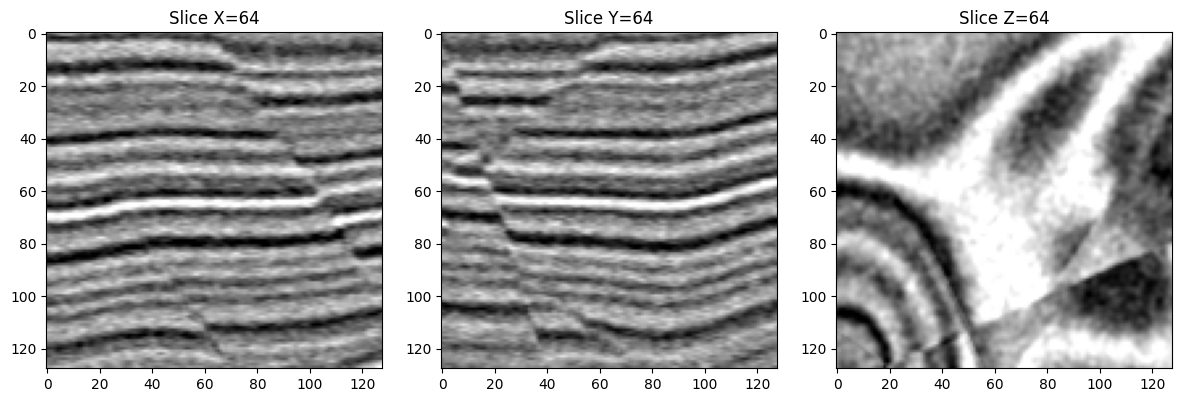

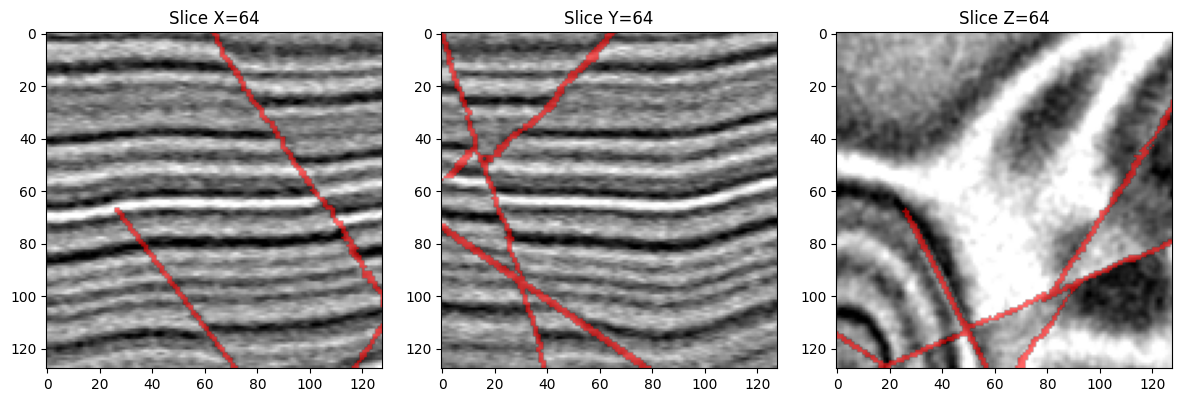



 showing index 4: img_0100.npy


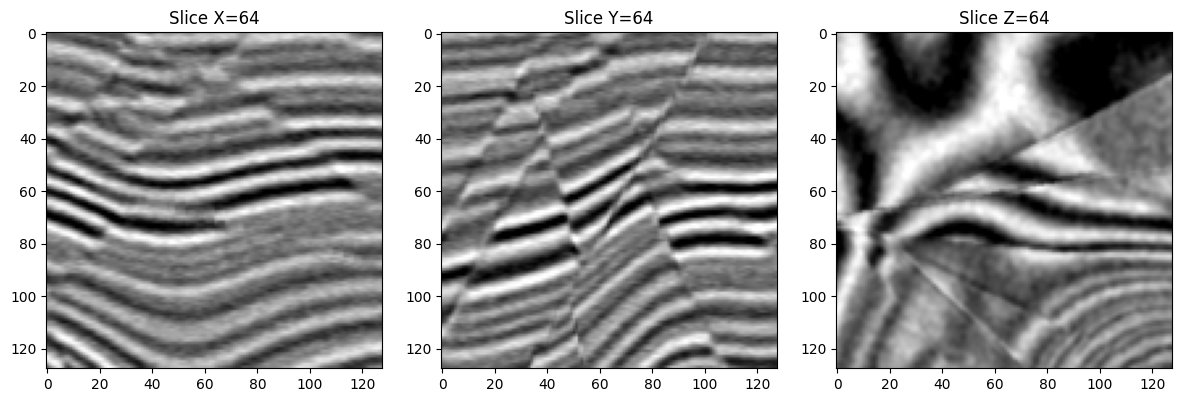

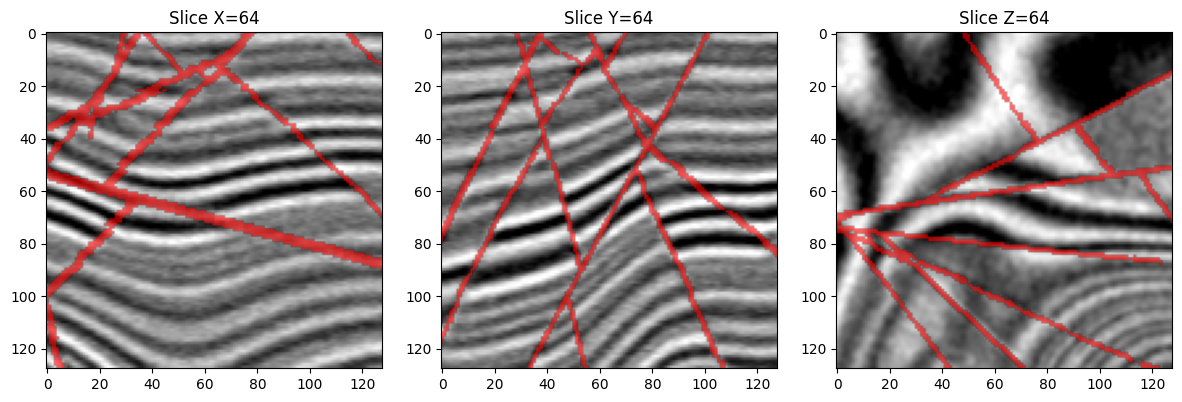



 showing index 5: img_0125.npy


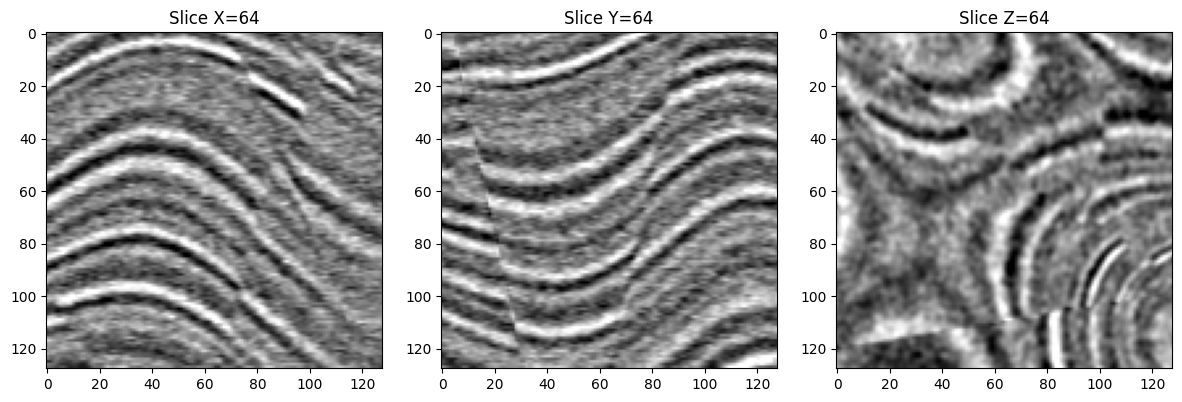

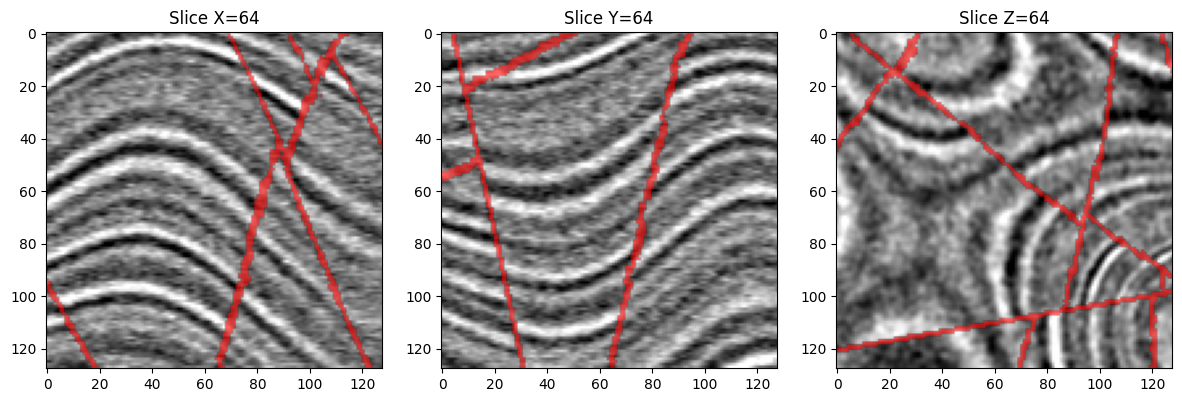

In [6]:
def getImage(base_path, file_name=None):
    path = os.path.join(base_path, file_name) if file_name else base_path
    return np.load(path)

def showTile(img=None, mask=None, save=None):
    if img is None and mask is None:
        return print("Erro: Forneça pelo menos 'img' ou 'mask'.")

    ref_vol = img if img is not None else mask
    mid_x = ref_vol.shape[0] // 2
    mid_y = ref_vol.shape[1] // 2
    mid_z = ref_vol.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        
        s_x = np.array(vol[mid_x, :, :]) # Plano YZ
        s_y = np.array(vol[:, mid_y, :]) # Plano XZ
        s_z = np.array(vol[:, :, mid_z]) # Plano XY
        return [s_x, np.rot90(s_z, -1), s_y]

    img_slices  = get_slices(img)
    mask_slices = get_slices(mask)
    cmap_mask_only    = ListedColormap(['black', 'red', 'green', 'blue'])
    cmap_mask_overlay = ListedColormap([(0, 0, 0, 0), 'red', 'green', 'blue'])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles    = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']

    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
            
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_mask_overlay, vmin=0, vmax=3, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_mask_only, vmin=0, vmax=3)
        
        ax.set_title(titles[i])

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
        return plt.close(fig)

    plt.show()

index = 0
for i, (img_path, msk_path) in enumerate(zip(images, masks)):
    if index > 5:
        break

    if i % 25 != 0:
        continue

    file_name = Path(img_path).name
    print(f'\n\n showing index {index}:', file_name)

    img  = getImage(img_path)
    mask = getImage(msk_path)

    showTile(img=img)
    showTile(img=img, mask=mask)
    index = index + 1

### Normalização com os trilhos do gerador
- O ganho de cada região satura bem menos de 1% dos voxels, então o percentil da amostra cairia dentro dos trilhos e mudaria com o número de tiles de cada região
- Os trilhos ±`clip` vêm do `synthetic.json`, a mesma escala em que a similaridade com o Marlim foi medida

In [7]:
(CLIP,) = {region['params']['clip'] for region in json.load(open('synthetic.json'))['regions'].values()}
p01, p99 = -CLIP, CLIP
print(p01, p99)

def normalize(img):
    clipped = np.clip(img, p01, p99)   
    return (clipped - p01) / (p99 - p01)

-2.42 2.42


In [8]:
setFolder('images')
setFolder('masks')

for img_path, msk_path in tqdm(zip(images, masks), total=len(images)):
    img = getImage(img_path)
    msk = getImage(msk_path)

    img = normalize(img)
    file_name = Path(img_path).name
    
    np.save(os.path.join('images', file_name), img)
    np.save(os.path.join('masks',  file_name),  msk)

  0%|          | 0/220 [00:00<?, ?it/s]

  5%|▍         | 10/220 [00:00<00:02, 92.97it/s]

  9%|▉         | 20/220 [00:00<00:02, 94.36it/s]

 14%|█▎        | 30/220 [00:00<00:01, 95.04it/s]

 18%|█▊        | 40/220 [00:00<00:01, 95.01it/s]

...

 84%|████████▎ | 184/220 [00:01<00:00, 99.35it/s]

 89%|████████▊ | 195/220 [00:01<00:00, 99.99it/s]

 93%|█████████▎| 205/220 [00:02<00:00, 98.03it/s]

 98%|█████████▊| 216/220 [00:02<00:00, 98.75it/s]

100%|██████████| 220/220 [00:02<00:00, 97.69it/s]

In [9]:
df = [] 

for img_path, mask_path in tqdm(zip(getFiles('images'), getFiles('masks'))):
    img  = np.load(img_path)
    mask = np.load(mask_path)
    data = dict()

    data['id'] = Path(img_path).name
    data['img_min']  = np.min(img)
    data['img_max']  = np.max(img)
    data['img_mean'] = np.mean(img)
    data['img_std']  = np.std(img)

    data['msk_min'] = np.min(mask)
    data['msk_max'] = np.max(mask)

    data['shape'] = img.shape
    data['img_path']  = img_path
    data['mask_path'] = mask_path
    df.append(data)


df = pd.DataFrame(df)
print(df.img_path.iloc[2])
df

0it [00:00, ?it/s]

21it [00:00, 208.68it/s]

43it [00:00, 213.77it/s]

65it [00:00, 210.49it/s]

87it [00:00, 210.77it/s]

...

177it [00:00, 216.20it/s]

201it [00:00, 220.70it/s]

220it [00:01, 217.46it/s]

/home/grva-mint/Projects/Falhas/Dataset/dataset_regions/images/img_0002.npy


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,img_0000.npy,0.0,1.0,0.500353,0.205291,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
1,img_0001.npy,0.0,1.0,0.500091,0.205435,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
2,img_0002.npy,0.0,1.0,0.499284,0.196782,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
3,img_0003.npy,0.0,1.0,0.499966,0.206181,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
4,img_0004.npy,0.0,1.0,0.496712,0.193001,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
...,...,...,...,...,...,...,...,...,...,...
215,img_0215.npy,0.0,1.0,0.501089,0.201841,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
216,img_0216.npy,0.0,1.0,0.499902,0.205079,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
217,img_0217.npy,0.0,1.0,0.502497,0.198181,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
218,img_0218.npy,0.0,1.0,0.500189,0.200868,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [10]:
if OPTIONS.get('img_size') is None:
    df.to_csv('DataBase.csv', index=None)
    display(df)
    sys.exit("Finalizando o programa: sem tiles nessa rodada")

,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,img_0000.npy,0.0,1.0,0.500353,0.205291,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
1,img_0001.npy,0.0,1.0,0.500091,0.205435,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
2,img_0002.npy,0.0,1.0,0.499284,0.196782,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
3,img_0003.npy,0.0,1.0,0.499966,0.206181,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
4,img_0004.npy,0.0,1.0,0.496712,0.193001,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
...,...,...,...,...,...,...,...,...,...,...
215,img_0215.npy,0.0,1.0,0.501089,0.201841,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
216,img_0216.npy,0.0,1.0,0.499902,0.205079,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
217,img_0217.npy,0.0,1.0,0.502497,0.198181,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...
218,img_0218.npy,0.0,1.0,0.500189,0.200868,0,1,"(128, 128, 128)",/home/grva-mint/Projects/Falhas/Dataset/datase...,/home/grva-mint/Projects/Falhas/Dataset/datase...


SystemExit: Finalizando o programa: sem tiles nessa rodada

/home/grva-mint/anaconda3/envs/torch-gpu/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# TILES

In [ ]:
IMG_SIZE = tuple(OPTIONS['img_size'])
IMG_SIZE

In [ ]:
class TilesBuilder:
    def __init__(self, target_size=(8, 64, 128), main_dir='tiles'):
        if len(target_size) != 3 or any(int(size) <= 0 for size in target_size):
            raise ValueError(f'img_size precisa de 3 valores positivos (z, y, x), recebido: {target_size}')

        self.target_size = tuple(int(size) for size in target_size)
        self.main_dir    = main_dir

        if os.path.exists(main_dir):
            shutil.rmtree(main_dir)
        os.makedirs(main_dir)

    def update(self, file_path, target_dir, is_mask=False):
        folder = os.path.join(self.main_dir, target_dir)
        os.makedirs(folder, exist_ok=True)

        data = np.load(file_path)
        base_name     = os.path.splitext(os.path.basename(file_path))[0]
        z_t, y_t, x_t = self.target_size

        z_pad = (z_t - data.shape[0] % z_t) % z_t
        y_pad = (y_t - data.shape[1] % y_t) % y_t
        x_pad = (x_t - data.shape[2] % x_t) % x_t

        pad_mode    = 'constant' if is_mask else 'reflect'
        data_padded = np.pad(data, ((0, z_pad), (0, y_pad), (0, x_pad)), mode=pad_mode) if z_pad > 0 or y_pad > 0 or x_pad > 0 else data

        index = 0
        for z in range(0, data_padded.shape[0], z_t):
            for y in range(0, data_padded.shape[1], y_t):
                for x in range(0, data_padded.shape[2], x_t):
                    tile = data_padded[z:z+z_t, y:y+y_t, x:x+x_t]
                    save_path = os.path.join(folder, f'{base_name}_tile_{index:04d}.npy')

                    np.save(save_path, tile)
                    index = (index + 1)


# os tiles saem de images/ e masks/ (ja normalizados e com os eixos corrigidos), nao dos .dat originais
tileImages = getFiles('images')
tileMasks  = getFiles('masks')

tiles = TilesBuilder(target_size=IMG_SIZE, main_dir='tiles')
for img_path, mask_path in tqdm(zip(tileImages, tileMasks), total=len(tileImages)):
    tiles.update(img_path,  'images/', is_mask=False)
    tiles.update(mask_path, 'masks/',  is_mask=True)

In [ ]:
print(len(getFiles('tiles/images')), 'imagens geradas')

In [ ]:
df = pd.DataFrame()
df['img_path']  = getFiles('tiles/images')
df['mask_path'] = getFiles('tiles/masks')

assert len(df) > 0, 'nenhum tile foi gerado'
assert [Path(p).stem for p in df.img_path] == [Path(p).stem for p in df.mask_path], 'tiles de imagem e mascara desalinhados'

stats = []
for path in tqdm(df.img_path, total=len(df)):
    tile = np.load(path)
    stats.append({
        'shape': tile.shape,
        'min':   np.min(tile),
        'max':   np.max(tile),
        'mean':  np.mean(tile),
        'std':   np.std(tile),
    })

for column in ['shape', 'min', 'max', 'mean', 'std']:
    df[column] = [item[column] for item in stats]

shapes = set(df['shape'])
assert shapes == {IMG_SIZE}, f'tiles com shape inesperado: {shapes} (esperado {IMG_SIZE})'

print(df.img_path.iloc[0])
df.to_csv('DataBase.csv', index=None)
df